# Feature Extraction

## Imports

In [1]:
from pathlib import Path, PurePath
import mne
%matplotlib inline
mne.viz.set_browser_backend("matplotlib")
import gpt3_tokenizer
from features import get_raw_tensor, get_feature_tensor
from torch.utils.data import Dataset

Using matplotlib as 2D backend.


## Load Data

In [2]:
class Session:
    def __init__(self, kind: str):
        self.raw = None
        self.stages = {}
        self.kind = kind
        self.tensors = {}

    def set_tensors(self):
        keys = list(self.stages.keys())
        tensor = dict.fromkeys(keys)
        for stage in tensor:
            tensor[stage] = {"raw": None, "processed": None}
            tensor[stage]["raw"] = get_raw_tensor(self.stages[stage])
            tensor[stage]["processed"] = get_feature_tensor(
                self.stages[stage], self.kind
            )
        self.tensors = tensor

    def get_tensors(self):
        return self.tensors

    def get_stages(self):
        return self.stages

In [3]:
baseline = []
main = []

preprocessed_dir = Path("./../EEG_data/preprocessed/")
# paths for baseline and main folders
baseline_dir = preprocessed_dir / "baseline"
main_dir = preprocessed_dir / "main"

bs_stages = ["eyes closed", "eyes open"]
mn_stages = [
    "red_screen_0",
    "reading_1",
    "red_screen_1",
    "reading_2",
    "red_screen_2",
    "reading_3",
    "red_screen_3",
    "reading_4",
    "red_screen_4",
    "reading_5",
]
# populate baseline
for session in baseline_dir.iterdir():
    sess = Session(kind="bs")
    st_dict = dict.fromkeys(bs_stages)
    bs_fif = list(session.glob("*.fif"))[0]
    fif = mne.io.read_raw_fif(bs_fif)
    sess.raw = fif
    for stage in session.iterdir():
        if stage != bs_fif:
            for fif_file in stage.iterdir():
                fif = mne.read_epochs(fif_file)
                key = PurePath(stage).name
                st_dict[key] = fif
    sess.stages = st_dict
    baseline.append(sess)
# populate main
for session in main_dir.iterdir():
    sess = Session(kind="mn")
    st_dict = dict.fromkeys(mn_stages)
    mn_fif = list(session.glob("*.fif"))[0]
    fif = mne.io.read_raw_fif(mn_fif)
    sess.raw = fif
    for stage in session.iterdir():
        if stage != mn_fif:
            for fif_file in stage.iterdir():
                fif = mne.read_epochs(fif_file)
                key = PurePath(stage).name
                st_dict[key] = fif
    sess.stages = st_dict
    main.append(sess)

Opening raw data file ../EEG_data/preprocessed/baseline/2026-04-10_Aminov/2026-04-10_Aminov_raw.fif...
    Range : 0 ... 150167 =      0.000 ...   600.668 secs
Ready.
Reading /Users/fountainer/Downloads/eeg research/eeg-to-code/feature_extraction/../EEG_data/preprocessed/baseline/2026-04-10_Aminov/eyes open/2026-04-10_Aminov_epo.fif ...
    Found the data of interest:
        t =       0.00 ...   14996.00 ms
        0 CTF compensation matrices available
Not setting metadata
20 matching events found
No baseline correction applied
0 projection items activated
Reading /Users/fountainer/Downloads/eeg research/eeg-to-code/feature_extraction/../EEG_data/preprocessed/baseline/2026-04-10_Aminov/eyes closed/2026-04-10_Aminov_epo.fif ...
    Found the data of interest:
        t =       0.00 ...   14996.00 ms
        0 CTF compensation matrices available
Not setting metadata
19 matching events found
No baseline correction applied
0 projection items activated
Opening raw data file ../EEG_data/pre

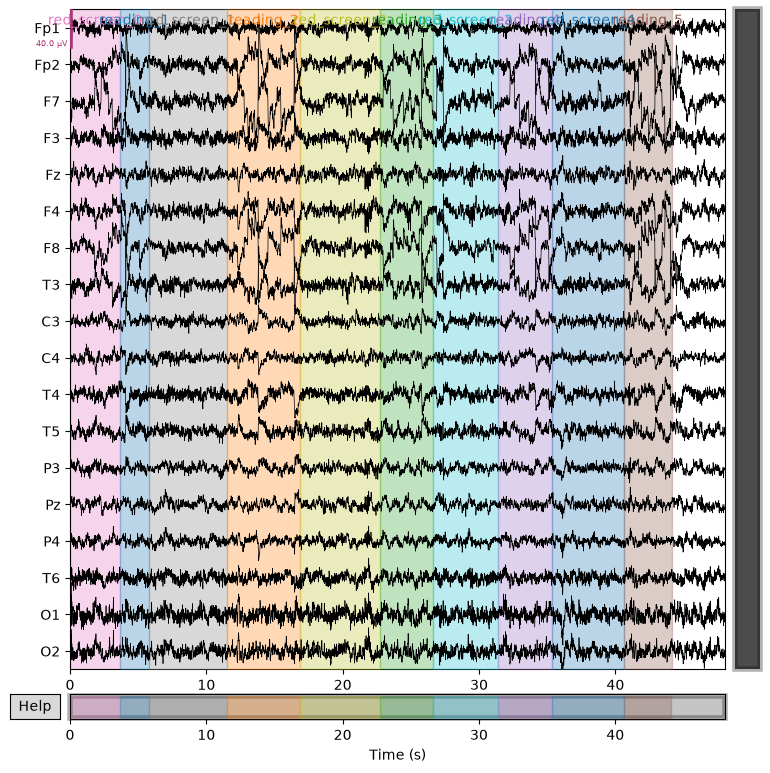

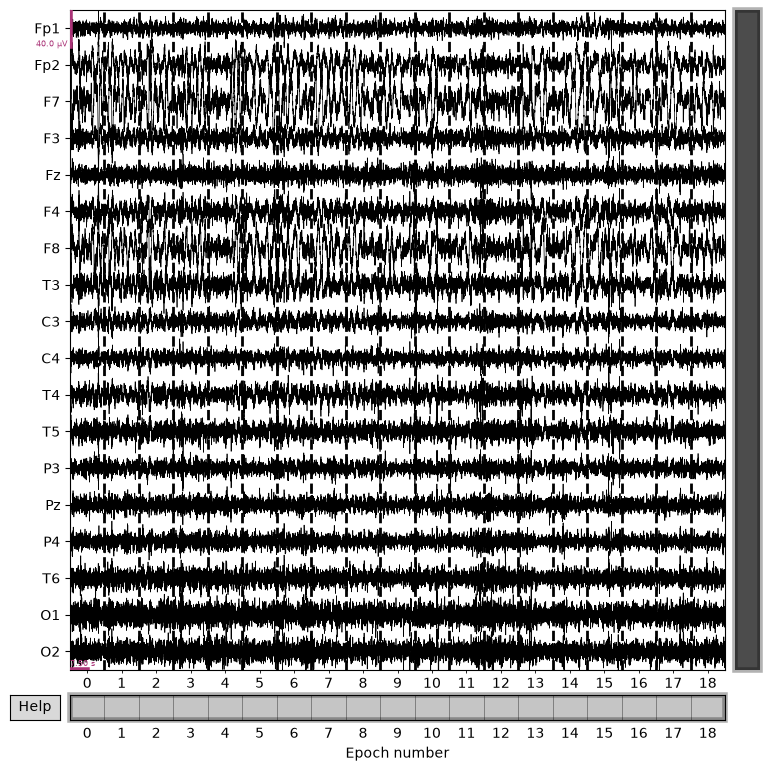

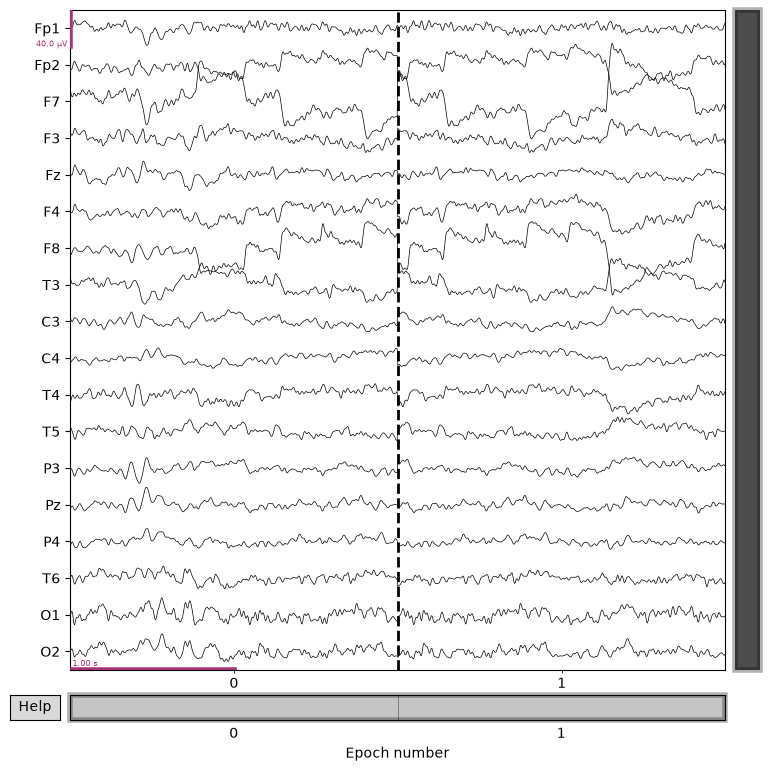

    Using multitaper spectrum estimation with 7 DPSS windows
Plotting power spectral density (dB=True).


/Users/fountainer/.pyenv/versions/eeg-to-code/lib/python3.14/site-packages/mne/viz/utils.py:160: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  (fig or plt).show(**kwargs)


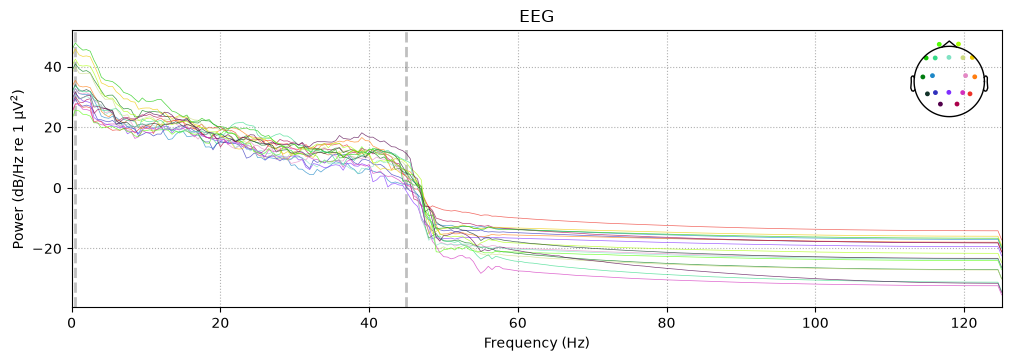

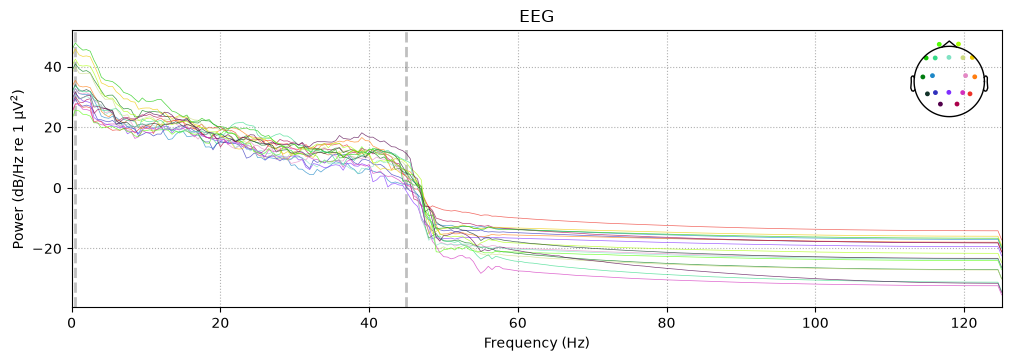

In [4]:
# loaded data examples
main[0].raw.plot(duration=50)
baseline[0].stages["eyes closed"].plot()
main[0].stages["reading_5"].plot()
main[0].stages["reading_1"].compute_psd().plot()

## Get Feature Tensors

In [5]:
get_feature_tensor(main[0].stages["reading_5"], "mn")

tensor([[5.5982e-01, 6.4251e-02, 2.7777e-01, 3.7688e-02, 8.1940e-03, 3.7390e-01,
         1.0537e-01, 3.2783e-01, 1.2344e-01, 3.4393e-02, 6.9767e-01, 7.2679e-02,
         1.0014e-01, 2.4860e-02, 4.1596e-03, 2.8666e-01, 2.4483e-01, 1.8192e-01,
         2.0753e-01, 2.1075e-02, 3.6090e-01, 2.8345e-01, 2.3948e-01, 1.0094e-01,
         6.3368e-03, 5.2522e-01, 1.0737e-01, 2.0662e-01, 9.7187e-02, 2.5815e-02,
         4.5590e-01, 8.7938e-02, 3.2939e-01, 6.0375e-02, 4.3493e-03, 7.6841e-01,
         4.3469e-02, 9.0000e-02, 1.2011e-02, 2.4552e-03, 2.4166e-01, 3.1151e-01,
         2.1521e-01, 1.8400e-01, 1.3407e-02, 6.7836e-01, 3.3328e-02, 1.0783e-01,
         8.8285e-02, 4.2785e-03, 1.7122e-01, 9.4139e-02, 4.5404e-01, 2.3258e-01,
         1.9669e-02, 3.8627e-01, 9.3272e-02, 3.9400e-01, 8.1064e-02, 2.8908e-02,
         1.9395e-01, 1.7961e-01, 5.1272e-01, 9.5542e-02, 5.7581e-03, 4.7659e-01,
         3.4525e-02, 3.9405e-01, 7.4713e-02, 2.9535e-03, 6.1746e-01, 6.4538e-02,
         1.7313e-01, 6.5390e

In [6]:
for session in main:
    session.set_tensors()

for session in baseline:
    session.set_tensors()

# Tokenize Prompts

In [7]:
prompts = [
    "Write a function to compute the area of a rectangle",
    "Write a function to compute the perimeter of a circle by radius",
    "Write a function to convert Celsius to Farenheit",
    "Write a function to check if a number is prime",
    "Write a function to return the factorial of n",
]

tokens = [gpt3_tokenizer.encode(prompt) for prompt in prompts]

for prompt, token in zip(prompts, tokens):
    print(prompt, ":", token)

annotations = {
    "reading_1": {"prompt": prompts[0], "tokens": tokens[0]},
    "reading_2": {"prompt": prompts[1], "tokens": tokens[1]},
    "reading_3": {"prompt": prompts[2], "tokens": tokens[2]},
    "reading_4": {"prompt": prompts[3], "tokens": tokens[3]},
    "reading_5": {"prompt": prompts[4], "tokens": tokens[4]},
}

Write a function to compute the area of a rectangle : [16594, 257, 2163, 284, 24061, 262, 1989, 286, 257, 35991]
Write a function to compute the perimeter of a circle by radius : [16594, 257, 2163, 284, 24061, 262, 25317, 286, 257, 9197, 416, 16874]
Write a function to convert Celsius to Farenheit : [16594, 257, 2163, 284, 10385, 34186, 284, 376, 5757, 29361]
Write a function to check if a number is prime : [16594, 257, 2163, 284, 2198, 611, 257, 1271, 318, 6994]
Write a function to return the factorial of n : [16594, 257, 2163, 284, 1441, 262, 1109, 5132, 286, 299]


## Create a Custom EEG Dataset Class

In [8]:
# structure of input & output

# for one session main[0]
# for each stage & each epoch ([0] is an epoch)
main[0].get_tensors()["reading_1"]["raw"][0]  # first input tensor
main[0].get_tensors()["reading_1"]["processed"][0]  # second input tensor
# for the whole session I will additionally feed session baselines so the model uses it
baseline[0].get_tensors()["eyes closed"]["processed"]  # baseline input tensor
annotations["reading_1"]["tokens"]  # output label

# so the input is
# tuple(main[0].get_tensors()["reading_1"]["raw"][0],
#   main[0].get_tensors()["reading_1"]["processed"][0], baseline[0].get_tensors()["eyes open"]["processed"],
#    self.baseline[session_idx].get_tensors()["eyes closed"]["processed"])
# and the associated label is annotations["reading_1"]["tokens"]

[16594, 257, 2163, 284, 24061, 262, 1989, 286, 257, 35991]

In [9]:
# build an index for a dataset so each epoch is binded to a number
epochs = []
for session_ind, session in enumerate(main):
    for stage in session.get_stages():
        for epoch_ind, epoch in enumerate(stage):
            epochs.append((session_ind, stage, epoch_ind))
index_from_triple = dict.fromkeys(epochs)
index_from_idx = dict.fromkeys([x for x, y in enumerate(epochs)])
for ind, key in enumerate(index_from_triple):
    index_from_triple[key] = ind
    index_from_idx[ind] = key
print(index_from_triple)
print(index_from_idx)

{(0, 'red_screen_0', 0): 0, (0, 'red_screen_0', 1): 1, (0, 'red_screen_0', 2): 2, (0, 'red_screen_0', 3): 3, (0, 'red_screen_0', 4): 4, (0, 'red_screen_0', 5): 5, (0, 'red_screen_0', 6): 6, (0, 'red_screen_0', 7): 7, (0, 'red_screen_0', 8): 8, (0, 'red_screen_0', 9): 9, (0, 'red_screen_0', 10): 10, (0, 'red_screen_0', 11): 11, (0, 'reading_1', 0): 12, (0, 'reading_1', 1): 13, (0, 'reading_1', 2): 14, (0, 'reading_1', 3): 15, (0, 'reading_1', 4): 16, (0, 'reading_1', 5): 17, (0, 'reading_1', 6): 18, (0, 'reading_1', 7): 19, (0, 'reading_1', 8): 20, (0, 'red_screen_1', 0): 21, (0, 'red_screen_1', 1): 22, (0, 'red_screen_1', 2): 23, (0, 'red_screen_1', 3): 24, (0, 'red_screen_1', 4): 25, (0, 'red_screen_1', 5): 26, (0, 'red_screen_1', 6): 27, (0, 'red_screen_1', 7): 28, (0, 'red_screen_1', 8): 29, (0, 'red_screen_1', 9): 30, (0, 'red_screen_1', 10): 31, (0, 'red_screen_1', 11): 32, (0, 'reading_2', 0): 33, (0, 'reading_2', 1): 34, (0, 'reading_2', 2): 35, (0, 'reading_2', 3): 36, (0, 'rea

In [10]:
class EEGDataset(Dataset):
    def __init__(
        self,
        annotations,
        main_sessions,
        baseline_sessions,
        index_from_triple,
        index_from_idx,
    ):
        self.labels = annotations
        self.main = main_sessions
        self.baseline = baseline_sessions
        self.index_from_triple = index_from_triple
        self.index_from_idx = index_from_idx

    def __len__(self):
        return len(self.index_from_idx)

    def __getitem__(self, idx: int):
        session_idx, stage, epoch_idx = self.index_from_idx[idx]

        mn_tensors = self.main[session_idx].get_tensors()
        main_raw = mn_tensors[stage]["raw"][epoch_idx]
        main_feature = mn_tensors[stage]["processed"][epoch_idx]

        bs_tensors = self.baseline[session_idx].get_tensors()
        bs_open = bs_tensors["eyes open"]["processed"]
        bs_closed = bs_tensors["eyes closed"]["processed"]

        data = (main_raw, main_feature, bs_open, bs_closed)
        label = (stage, self.labels[stage]["tokens"])
        return data, label

    def get_item(self, session_idx, stage, epoch_idx):
        sample = self.__getitem__(
            idx=self.index_from_triple[(session_idx, stage, epoch_idx)]
        )
        return sample